# Very fast walk-through of Electric Vehicle case study in `bw_timex`

Here's a reminder of of the steps involved in a `TimexLCA`:


<div style="display: flex; justify-content: center; background-color: white; border-radius: 15px; padding: 10px; width: 600px; margin: auto;">
  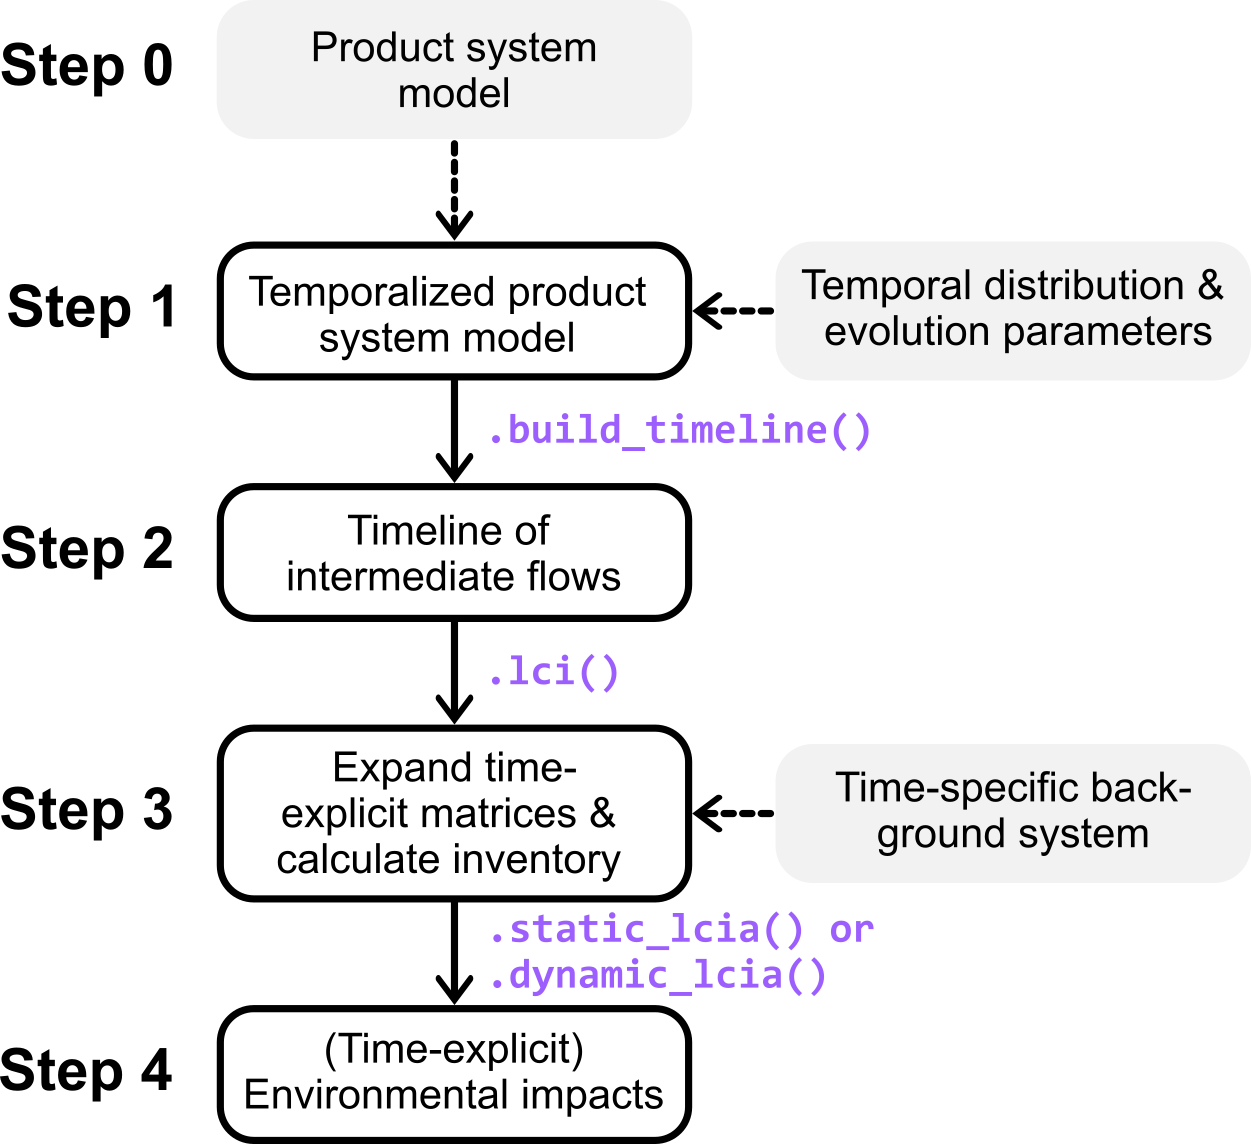
</div>

## **Step 0**: Product system _(normal brightway stuff)_


```mermaid
flowchart LR
    car_prod_wo_battery(🚗 market for passenger car, electric, without battery):::ei-->ev_production
    battery_production(🔋 market for battery, Li-ion, LiMn2O4, rechargeable):::ei-->ev_production
    ev_production(🔌🚗 ev assembly):::fg-->driving
    electricity_generation(⚡ market group for electricity, low voltage):::ei-->driving
    driving(🛣️ driving ev):::fg-->battery_eol(🗑️🔋 market for used Li-ion battery):::ei
    driving-->fu(FU: driving 100,000 km)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

Legend:

```mermaid
flowchart TB
    background(background process):::ei
    foreground(foreground process):::fg

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


In [1]:
# Creates product system above with normal Brightway commands
import bw2data as bd
bd.projects.set_current("ei312_REMIND_EU")

if "foreground" in bd.databases:
    del bd.databases["foreground"]  # to make sure we create the foreground from scratch
foreground = bd.Database("foreground")
foreground.register()

### Create foreground processes:
ev_production = foreground.new_node(
    "ev_production", name="assembly of an electric vehicle", unit="unit"
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

driving = foreground.new_node(
    "driving", name="driving an electric vehicle", unit="pkm over ev lifetime"
)
driving["reference product"] = "person transport"
driving.save()

### Add their exchanges:
LIFETIME = 15  # years
ELECTRICITY_CONSUMPTION = 0.2  # kWh/km
LIFETIME_KM = 100_000  # km
MASS_CAR_WITHOUT_BATTERY = 840  # kg
MASS_BATTERY = 280  # kg

BG_DATABASE = "ei312_REMIND-EU_SSP2_NDC_2020"

car_without_battery = bd.get_node(
    database=BG_DATABASE,
    name="market for passenger car, electric, without battery",
)
battery = bd.get_node(
    database=BG_DATABASE,
    name="market for battery, Li-ion, LiMn2O4, rechargeable",
)
electricity = bd.get_node(
    database=BG_DATABASE,
    name="market group for electricity, low voltage",
    location="GLO",
)
battery_eol = bd.get_node(
    database=BG_DATABASE,
    name="market for used Li-ion battery",
)

ev_production.new_edge(input=ev_production, amount=1, type="production").save()

car_without_battery_to_ev = ev_production.new_edge(
    input=car_without_battery, amount=MASS_CAR_WITHOUT_BATTERY, type="technosphere"
)
car_without_battery_to_ev.save()

battery_to_ev = ev_production.new_edge(
    input=battery, amount=MASS_BATTERY, type="technosphere"
)
battery_to_ev.save()

driving.new_edge(input=driving, amount=1, type="production").save()

ev_to_driving = driving.new_edge(input=ev_production, amount=1, type="technosphere")
ev_to_driving.save()

electricity_to_driving = driving.new_edge(
    input=electricity,
    amount=ELECTRICITY_CONSUMPTION * LIFETIME_KM,
    type="technosphere",
)
electricity_to_driving.save()

driving_to_battery_eol = driving.new_edge(
    input=battery_eol,
    amount=-MASS_BATTERY,  # used battery is "produced"
    type="technosphere",
)
driving_to_battery_eol.save()

### Running a standard "static" LCA


In [2]:
import bw2calc as bc

method = (
    "ecoinvent-3.12",
    "EF v3.1",
    "climate change",
    "global warming potential (GWP100)",
)
standard_lca = bc.LCA({driving: 1}, method)
standard_lca.lci()
standard_lca.lcia()
standard_lca.score #kg CO2-eq

21882.06254693395

## **Step 1**: Add temporal information 
_using the `TemporalDistribution` class that we will cover in detail in the next session._


```mermaid
flowchart LR
    car_prod_wo_battery(🚗 market for passenger car, electric, without battery):::ei-->|1-2 years prior|ev_production
    battery_production(🔋 market for battery, Li-ion, LiMn2O4, rechargeable):::ei-->|6-9 months prior|ev_production
    ev_production(🔌🚗 ev assembly):::fg-->|1-3 months prior|driving
    electricity_generation(⚡ market group for electricity, low voltage):::ei-->|uniformly distributed over lifetime|driving
    driving(🛣️ driving ev):::fg-->|3 months after lifetime|battery_eol(🗑️🔋 market for used Li-ion battery):::ei
    driving-->fu(**FU**: driving 100,000 km, *uniformly over lifetime, starting 2025*)

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


In [3]:
#this cell attaches to each exchange the relative temporal distribution as shown above.
from bw_timex import TemporalDistribution
import numpy as np

#defining a temporal distribution
td_car_without_battery_production = TemporalDistribution(
    date=np.array([-2, -1], dtype="timedelta64[Y]"),  # yearly resolution
    amount=np.array([0.2, 0.8]),
)

td_assembly_and_delivery = TemporalDistribution(
    date=np.array([-3, -2, -1], dtype="timedelta64[M]"),  # monthly resolution
    amount=np.array([0.3, 0.5, 0.2]),
)
td_battery_eol = TemporalDistribution(
    date=np.array([LIFETIME * 12 + 3], dtype="timedelta64[M]"), amount=np.array([1])
)

from bw_timex import easy_timedelta_distribution
#there is also a convenience function
td_battery_production = easy_timedelta_distribution(
    start=-9,
    end=-6,
    resolution="M",
    steps=4,
    kind="normal",  # you can also use "uniform" or "triangular"
    param=0.5,
)

td_electricity_consumption = easy_timedelta_distribution(
    start=0,
    end=LIFETIME,
    resolution="Y",
    steps=(LIFETIME + 1),
    kind="uniform",
)

#Attach the temporal distributions to the exchanges
car_without_battery_to_ev["temporal_distribution"] = td_car_without_battery_production
car_without_battery_to_ev.save()

battery_to_ev["temporal_distribution"] = td_battery_production
battery_to_ev.save()

ev_to_driving["temporal_distribution"] = td_assembly_and_delivery
ev_to_driving.save()

#There is also a convenience function to attach temporal distributions to exchanges,
from bw_timex.utils import add_temporal_distribution_to_exchange

add_temporal_distribution_to_exchange(
    td_electricity_consumption,
    input_node=electricity,
    output_node=driving,
)

add_temporal_distribution_to_exchange(
    td_battery_eol,
    input_node=battery_eol,
    output_node=driving,
)

2026-09-17 17:32:14.240 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 20000.0 kilowatt hour 'market group for electricity, low voltage' (kilowatt hour, GLO, None) to 'driving an electric vehicle' (pkm over ev lifetime, GLO, None).
2026-09-17 17:32:14.293 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: -280 kilogram 'market for used Li-ion battery' (kilogram, GLO, None) to 'driving an electric vehicle' (pkm over ev lifetime, GLO, None).


## **Step 2-4**: Calculate a time-explicit LCA


In [4]:
from bw_timex import TimexLCA

tlca = TimexLCA(demand={driving: 1}, method=method) 
tlca.build_timeline(starting_datetime="2025-01-01", temporal_grouping="month", graph_traversal="bfs")
tlca.lci()
tlca.static_lcia()
tlca.static_score

2026-09-17 17:32:14.350 | INFO     | bw_timex.timex_lca:__init__:445 - Initializing TimexLCA object...
2026-09-17 17:32:14.354 | INFO     | bw_timex.timex_lca:__init__:534 - Calculating base LCA...
2026-09-17 17:32:14.358 | INFO     | bw_timex.timex_lca:clean_databases:2557 - Reprocessing 1 modified database(s) before calculating: foreground. This can take a while for large databases.
2026-09-17 17:32:14.425 | INFO     | bw_timex.timex_lca:clean_databases:2563 - Done reprocessing modified databases.
2026-09-17 17:32:16.239 | INFO     | bw_timex.timex_lca:__init__:591 - Collecting node infos...
2026-09-17 17:32:16.492 | INFO     | bw_timex.timex_lca:__init__:606 - Loading node metadata from 10 database(s)...
2026-09-17 17:33:03.964 | INFO     | bw_timex.timex_lca:__init__:674 - TimexLCA initialized.
2026-09-17 17:33:03.995 | INFO     | bw_timex.timex_lca:build_timeline:1279 - No edge filter function provided. Skipping all edges in background databases.
2026-09-17 17:33:04.286 | INFO    

13371.69521614428

Compare this to the score of our "normal" static lca before:

In [5]:
print(standard_lca.score)
print("Time-explicit score is {:.1f}% lower.".format(((standard_lca.score - tlca.static_score) / standard_lca.score * 100)))

21882.06254693395
Time-explicit score is 38.9% lower.


We can also plot the time-explicit results as a waterfall chart with time as x-axis:

2026-09-17 17:33:23.876 | INFO     | dynamic_characterization.dynamic_characterization:characterize:135 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


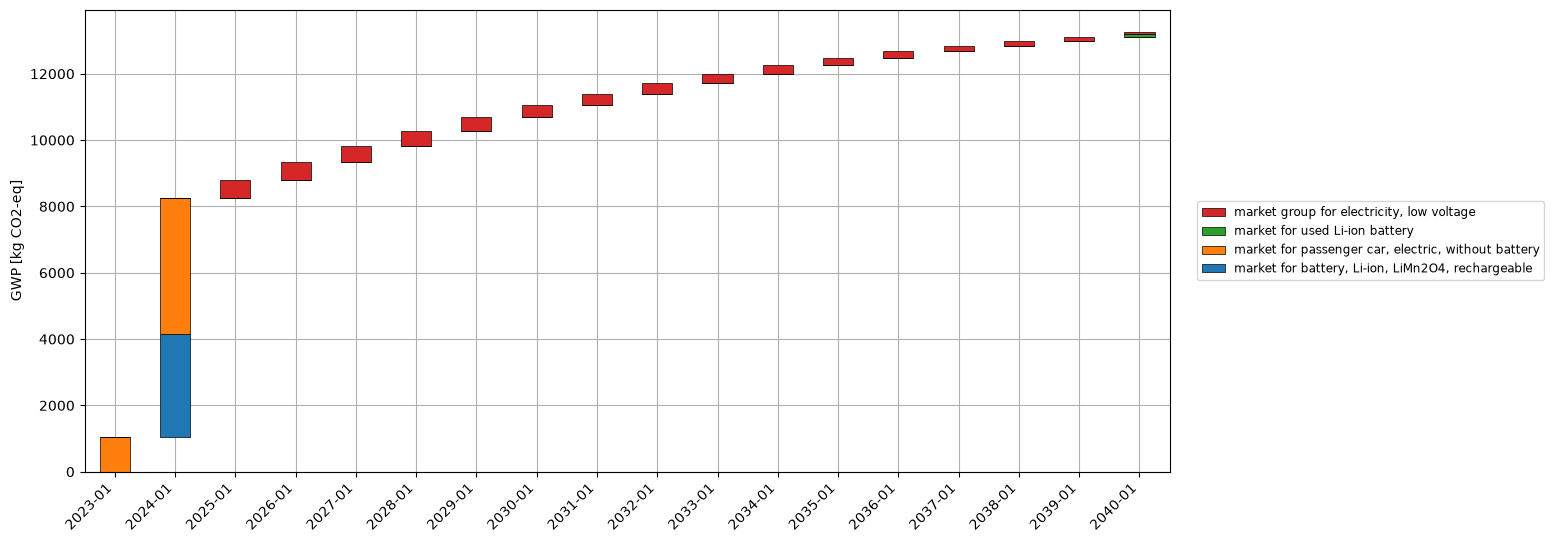

In [6]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall
tlca.dynamic_lcia(metric="GWP")
plot_characterized_inventory_as_waterfall(tlca)